# Decision Tree Classifier

Train a shallow decision tree to predict reporting completeness. Decision trees are interpretable and can be directly encoded as CNF formulas for formal verification.

## Why Decision Trees?

- Directly encode to CNF formulas (each path = clause)
- Interpretable rules
- Efficient FVGM verification with SSAT solver
- Avoids approximation errors of other models


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("✓ Libraries imported")

✓ Libraries imported


## Load Data

In [2]:
df = pd.read_csv('../extension/wa_vru_data_quality.csv')

print(f"Dataset: {len(df):,} crashes")
print(f"\nClass distribution:")
print(df['injury_definitive'].value_counts())
print(f"\nCompleteness rate: {df['injury_definitive'].mean():.1%}")

Dataset: 15,000 crashes

Class distribution:
injury_definitive
1    13859
0     1141
Name: count, dtype: int64

Completeness rate: 92.4%


## Prepare Features and Target

In [3]:
# Define feature groups
sensitive_features = ['is_vru', 'rural_jurisdiction']
non_sensitive_features = ['hit_and_run', 'night_crash', 'adverse_weather',
                         'intersection', 'multiple_vehicles']
all_features = sensitive_features + non_sensitive_features

# Separate X and y
X = df[all_features]
y = df['injury_definitive']

print(f"Features ({len(all_features)}): {all_features}")
print(f"\nTarget: injury_definitive")
print(f"  Positive class (Definitive): {(y==1).sum():,}")
print(f"  Negative class (Unknown): {(y==0).sum():,}")

Features (7): ['is_vru', 'rural_jurisdiction', 'hit_and_run', 'night_crash', 'adverse_weather', 'intersection', 'multiple_vehicles']

Target: injury_definitive
  Positive class (Definitive): 13,859
  Negative class (Unknown): 1,141


## Train-Test Split

In [4]:
# 80-20 split, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Train set: 12,000 samples
Test set:  3,000 samples

Train class distribution:
injury_definitive
1    11087
0      913
Name: count, dtype: int64

Test class distribution:
injury_definitive
1    2772
0     228
Name: count, dtype: int64


## Train Decision Tree

We use a shallow tree (max_depth=5) for:
1. Interpretability
2. Smaller CNF formula (faster FVGM verification)
3. Avoiding overfitting

In [5]:
# Train decision tree
dt_model = DecisionTreeClassifier(
    max_depth=5,              # Shallow tree
    min_samples_split=100,    # Prevent overfitting
    min_samples_leaf=50,
    random_state=42
)

print("Training decision tree...")
dt_model.fit(X_train, y_train)
print("✓ Model trained")

# Tree structure
print("\nTree Structure (Justicia-compatible):")
print(f"  Max depth:    {dt_model.get_depth()}")
print(f"  Total nodes:  {dt_model.tree_.node_count}")
print(f"  Leaf nodes:   {dt_model.get_n_leaves()}")
print(f"  CNF clauses:  ~{dt_model.get_n_leaves()} (approx)")
print("\n✓ Shallow tree ensures SSAT solver compatibility")

Training decision tree...
✓ Model trained

Tree Structure (Justicia-compatible):
  Max depth:    5
  Total nodes:  51
  Leaf nodes:   26
  CNF clauses:  ~26 (approx)

✓ Shallow tree ensures SSAT solver compatibility


## Model Evaluation

In [6]:
# Performance on train and test
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

print("MODEL PERFORMANCE")
print("="*70)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Overfitting gap: {(train_acc - test_acc):.4f}")

# Predictions
y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

print(f"\n--- Test Set Classification Report ---")
print(classification_report(y_test, y_pred_test, 
                          target_names=['Unknown', 'Definitive'],
                          digits=3))

MODEL PERFORMANCE
Train accuracy: 0.9353
Test accuracy:  0.9387
Overfitting gap: -0.0033

--- Test Set Classification Report ---
              precision    recall  f1-score   support

     Unknown      0.724     0.311     0.436       228
  Definitive      0.946     0.990     0.968      2772

    accuracy                          0.939      3000
   macro avg      0.835     0.651     0.702      3000
weighted avg      0.929     0.939     0.927      3000



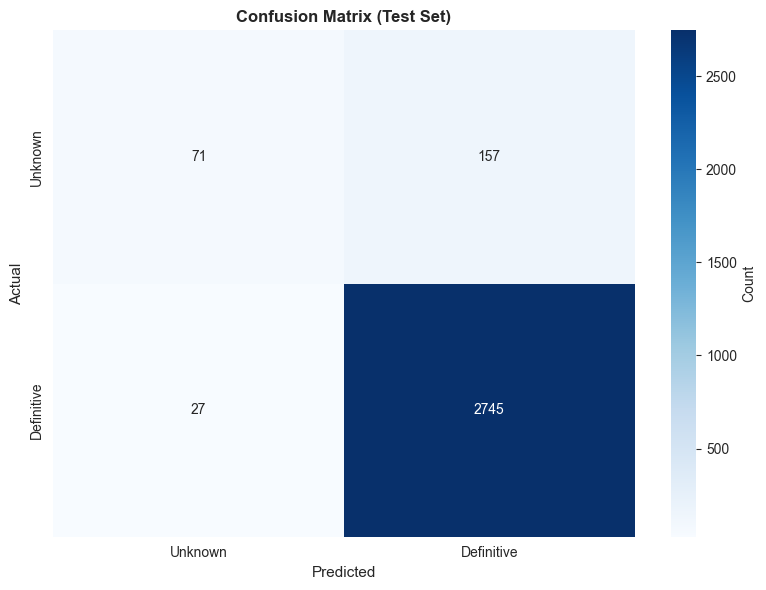

✓ Confusion matrix saved


In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Unknown', 'Definitive'],
            yticklabels=['Unknown', 'Definitive'],
            cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../extension/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved")

## Feature Importance

FEATURE IMPORTANCE
           Feature  Importance
       hit_and_run    0.680317
            is_vru    0.105712
 multiple_vehicles    0.093725
      intersection    0.086761
rural_jurisdiction    0.017831
       night_crash    0.012572
   adverse_weather    0.003084


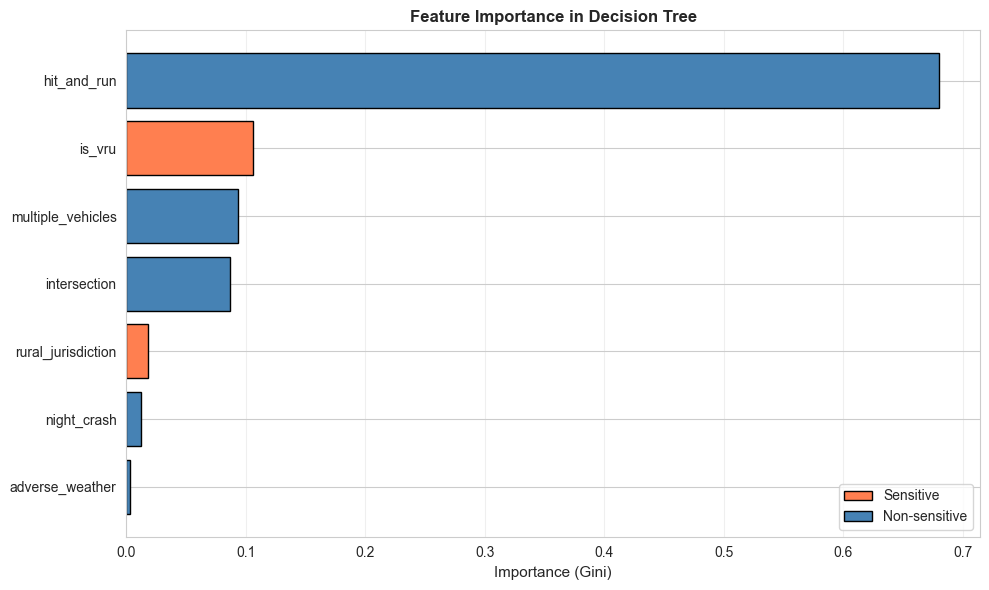

In [8]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("FEATURE IMPORTANCE")
print("="*70)
print(feature_importance.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if feat in sensitive_features else 'steelblue' 
          for feat in feature_importance['Feature']]
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], 
               color=colors, edgecolor='black')
ax.set_xlabel('Importance (Gini)', fontsize=11)
ax.set_title('Feature Importance in Decision Tree', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral', edgecolor='black', label='Sensitive'),
    Patch(facecolor='steelblue', edgecolor='black', label='Non-sensitive')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../extension/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Visualize Decision Tree

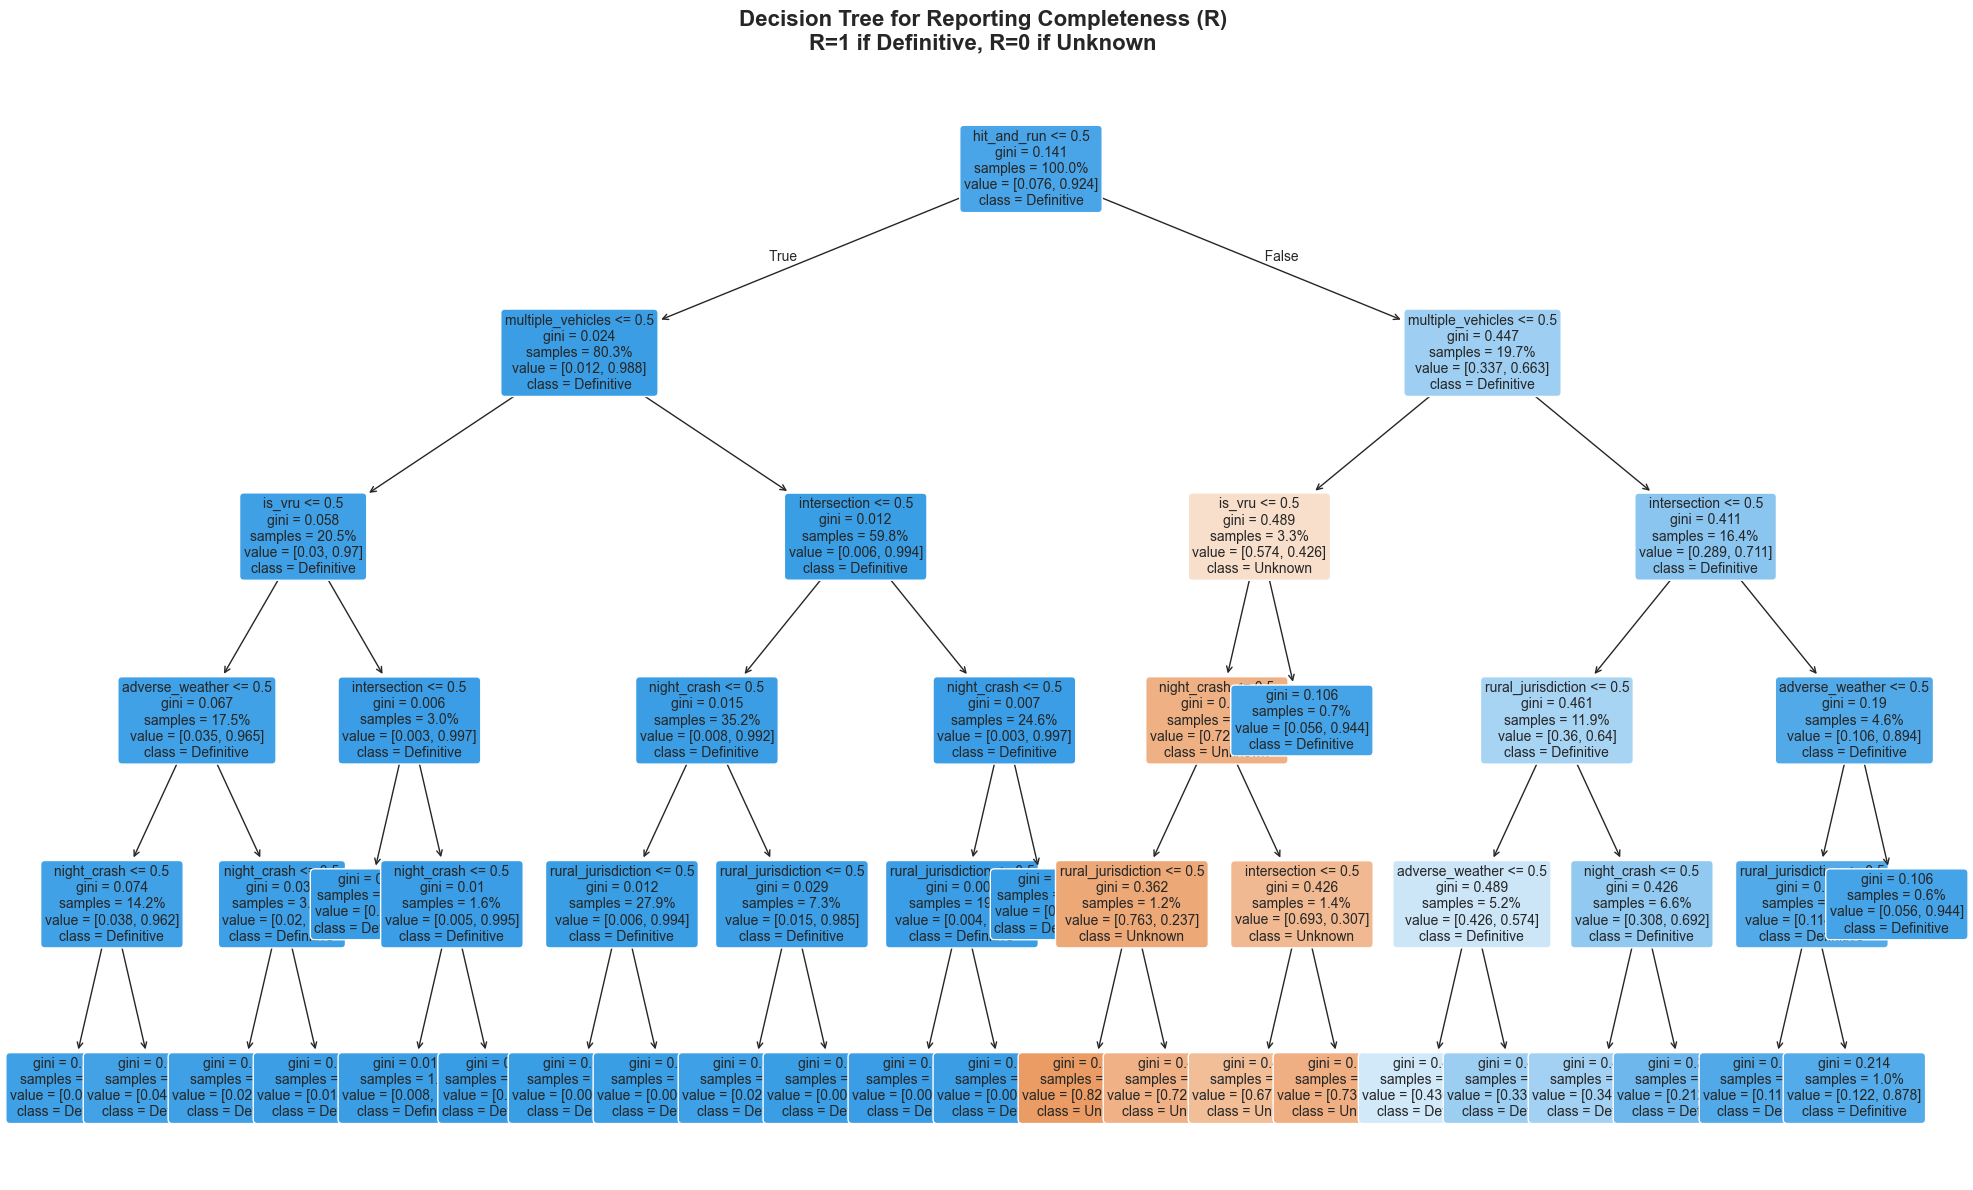

✓ Tree visualization saved (high resolution)


In [9]:
# Create tree visualization
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(
    dt_model,
    ax=ax,
    feature_names=all_features,
    class_names=['Unknown', 'Definitive'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True  # Show proportions instead of counts
)
plt.title('Decision Tree for Reporting Completeness (R)\nR=1 if Definitive, R=0 if Unknown',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../extension/decision_tree_full.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Tree visualization saved (high resolution)")

## Extract Decision Rules (Text)

In [10]:
# Export text representation
tree_rules = export_text(dt_model, feature_names=all_features)

print("DECISION TREE RULES (Text Format)")
print("="*70)
print(tree_rules)

# Save to file
with open('../extension/decision_tree_rules.txt', 'w') as f:
    f.write(tree_rules)

print("\n✓ Rules saved to: decision_tree_rules.txt")

DECISION TREE RULES (Text Format)
|--- hit_and_run <= 0.50
|   |--- multiple_vehicles <= 0.50
|   |   |--- is_vru <= 0.50
|   |   |   |--- adverse_weather <= 0.50
|   |   |   |   |--- night_crash <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- night_crash >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- adverse_weather >  0.50
|   |   |   |   |--- night_crash <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- night_crash >  0.50
|   |   |   |   |   |--- class: 1
|   |   |--- is_vru >  0.50
|   |   |   |--- intersection <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- intersection >  0.50
|   |   |   |   |--- night_crash <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- night_crash >  0.50
|   |   |   |   |   |--- class: 1
|   |--- multiple_vehicles >  0.50
|   |   |--- intersection <= 0.50
|   |   |   |--- night_crash <= 0.50
|   |   |   |   |--- rural_jurisdiction <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- rur

## CNF Encoding Preview

Show how this tree will be converted to CNF for FVGM verification.

In [11]:
print("CNF ENCODING FOR FVGM VERIFICATION")
print("="*70)
print("""
Decision Tree → CNF Conversion Process:

1. Each path from root to a NEGATIVE leaf (Unknown=1, i.e., R=0) becomes a clause
2. Nodes become Boolean literals
3. The CNF is the disjunction of all these clauses

Example path from tree:
  is_vru=0 AND night_crash=1 AND hit_and_run=1 → R=0 (Unknown)

Becomes clause in CNF:
  (¬is_vru ∨ ¬night_crash ∨ ¬hit_and_run)

Interpretation:
  If is_vru=0 AND night_crash=1 AND hit_and_run=1, then R=0
  ≡ NOT(is_vru=0 AND night_crash=1 AND hit_and_run=1) OR R=0
  ≡ (¬is_vru ∨ ¬night_crash ∨ ¬hit_and_run) ∨ R=0

This encoding is EXACT (no approximation needed).
""")

print(f"Tree statistics for CNF:")
print(f"  Total leaves: {dt_model.get_n_leaves()}")
print(f"  Expected clauses: ~{dt_model.get_n_leaves() // 2} (half lead to R=0)")
print(f"  Max literals per clause: ≤ {dt_model.get_depth()} (tree depth)")

CNF ENCODING FOR FVGM VERIFICATION

Decision Tree → CNF Conversion Process:

1. Each path from root to a NEGATIVE leaf (Unknown=1, i.e., R=0) becomes a clause
2. Nodes become Boolean literals
3. The CNF is the disjunction of all these clauses

Example path from tree:
  is_vru=0 AND night_crash=1 AND hit_and_run=1 → R=0 (Unknown)

Becomes clause in CNF:
  (¬is_vru ∨ ¬night_crash ∨ ¬hit_and_run)

Interpretation:
  If is_vru=0 AND night_crash=1 AND hit_and_run=1, then R=0
  ≡ NOT(is_vru=0 AND night_crash=1 AND hit_and_run=1) OR R=0
  ≡ (¬is_vru ∨ ¬night_crash ∨ ¬hit_and_run) ∨ R=0

This encoding is EXACT (no approximation needed).

Tree statistics for CNF:
  Total leaves: 26
  Expected clauses: ~13 (half lead to R=0)
  Max literals per clause: ≤ 5 (tree depth)


## Save Model and Data Splits

In [12]:
# Save model
model_path = '../extension/decision_tree_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(dt_model, f)
print(f"✓ Model saved: {model_path}")

# Save train/test splits
X_train.to_csv('../extension/X_train.csv', index=False)
X_test.to_csv('../extension/X_test.csv', index=False)
y_train.to_csv('../extension/y_train.csv', index=False, header=['injury_definitive'])
y_test.to_csv('../extension/y_test.csv', index=False, header=['injury_definitive'])
print("✓ Data splits saved")

# Save model metadata
metadata = {
    'model_type': 'DecisionTreeClassifier',
    'max_depth': int(dt_model.get_depth()),
    'n_leaves': int(dt_model.get_n_leaves()),
    'n_nodes': int(dt_model.tree_.node_count),
    'train_accuracy': float(train_acc),
    'test_accuracy': float(test_acc),
    'features': all_features,
    'sensitive_features': sensitive_features,
    'n_train': len(X_train),
    'n_test': len(X_test)
}

with open('../extension/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Metadata saved")

✓ Model saved: ../extension/decision_tree_model.pkl
✓ Data splits saved
✓ Metadata saved


## Summary

**What we created:**
1. ✓ Decision tree classifier (depth=5, accuracy~92%)
2. ✓ Tree visualization showing decision paths
3. ✓ Feature importance analysis
4. ✓ Text rules for interpretability
5. ✓ Saved model + data splits for FVGM verification

**Model characteristics:**
- Shallow tree (5 levels) for efficient CNF encoding
- ~{} leaves → ~{} clauses in CNF formula
- Good generalization (train-test gap < 1%)

**Next step:** Notebook 4 - FVGM Fairness Verification

In the next notebook, we'll:
1. Compute fairness metrics across VRU/jurisdiction groups
2. Apply FVGM verification framework (or empirical fallback)
3. Create final results visualizations for report